# Training The Cannon with LAMOST x APOGEE data

## 1. Importing the training set

This section loads the training set built from the cross-match between LAMOST DR9 and APOGEE DR17.

The following files are loaded:

- **dataall**: spectra, wavelength grid, and flux uncertainties  
- **metaall**: stellar labels used for training  
- **tc_names**: LAMOST observation IDs  

The stellar labels included are:

- Teff  
- logg  
- Vmic  
- Ak  
- [Fe/H]  
- [Mg/Fe]  
- [Mn/Fe]  
- [Al/Fe]  
- [C/Fe]  
- [N/Fe]


In [1]:
# --------------------------------------------------
# Standard library
# --------------------------------------------------
import pickle
from pathlib import Path
import urllib.request

# --------------------------------------------------
# Third-party packages
# --------------------------------------------------
import numpy as np
from astropy.table import Table

# --------------------------------------------------
# Define local data directory
# --------------------------------------------------
# Expected project structure:
#
# project/
# ├── notebook.ipynb
# ├── data/
# │   └── trainingset_table.pickle
# --------------------------------------------------

data_path = Path("data")
data_path.mkdir(exist_ok=True)

# --------------------------------------------------
# Download training set from Zenodo if needed
# --------------------------------------------------

training_file = data_path / "trainingset_table.pickle"

url = "PASTE_YOUR_ZENODO_DIRECT_LINK_HERE"

if not training_file.exists():
    print("Training set not found locally. Downloading...")
    urllib.request.urlretrieve(url, training_file)
    print("Download completed.")
else:
    print("Training set already available locally.")

Training set already available locally.


In [2]:
# --------------------------------------------------
# Load training set
# --------------------------------------------------

training_file = data_path / "trainingset_table.pickle"

with open(training_file, "rb") as file_in:
    dataall, metaall, label_names, tc_names, _ = pickle.load(file_in)

# APOGEE label names
labels = [
    'TEFF',
    'LOGG',
    'VMICRO',
    'AK_WISE',
    'FE_H',
    'MG_FE',
    'MN_FE',
    'AL_FE',
    'C_FE',
    'N_FE'
]

# Convert labels into astropy table
sample_labels = Table(
    {label: col for label, col in zip(labels, metaall.T)}
)

In [5]:
# --------------------------------------------------
# Extract spectra and uncertainties
# --------------------------------------------------

# Flux
sample_flux = dataall[:, :, 1].T

# Flux uncertainty
sample_flux_err = dataall[:, :, 2].T

# Inverse variance
sample_ivar = 1 / sample_flux_err**2

In [7]:
# Check dimensions
print("Flux shape:", sample_flux.shape)
print("Flux error shape:", sample_flux_err.shape)

Flux shape: (15410, 3559)
Flux error shape: (15410, 3559)


## 2. Training The Cannon

In this section we train four different Cannon models using different spectral selections:

- **Full-spectrum model**: uses the full wavelength range (following Ness et al. 2025)
- **Absorption model**: uses only strong absorption features of each element
- **Telluric model**: increases flux uncertainties in telluric regions
- **Combined model**: absorption model + telluric treatment

In [10]:
# --------------------------------------------------
# Local utilities
# --------------------------------------------------
import functions as utils

# --------------------------------------------------
# Additional packages
# --------------------------------------------------
import thecannon as tc
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
# --------------------------------------------------
# Load wavelength grid
# --------------------------------------------------

wavelength_file = data_path / "wavelength_Wheeler20.txt"

LAMOST_wavelength = np.loadtxt(wavelength_file,usecols=(0,))


### 2.1 Full-spectrum model

We train a quadratic Cannon model using the full wavelength range.

In [16]:
# --------------------------------------------------
# Define model configuration
# --------------------------------------------------

order = 2
full_model_labels = tuple(sample_labels.colnames)

# Output directory for trained models
model_path = Path("tc_models")
model_path.mkdir(exist_ok=True)

# Model filename
full_model_file = model_path / "lamost_apogee_cannon_full_model.model"

# --------------------------------------------------
# Create Cannon model
# --------------------------------------------------

full_model = tc.CannonModel(
    sample_labels,
    sample_flux,
    sample_ivar,
    vectorizer=tc.vectorizer.PolynomialVectorizer(full_model_labels, order),
    dispersion=LAMOST_wavelength
)


In [18]:
# --------------------------------------------------
# Train model or load existing model
# --------------------------------------------------

model_file = full_model_file.with_suffix(".model")

full_model, full_model_theta, full_model_s = utils.train_or_load_model(
    full_model,
    full_model_file)

Existing model found: lamost_apogee_cannon_full_model.model


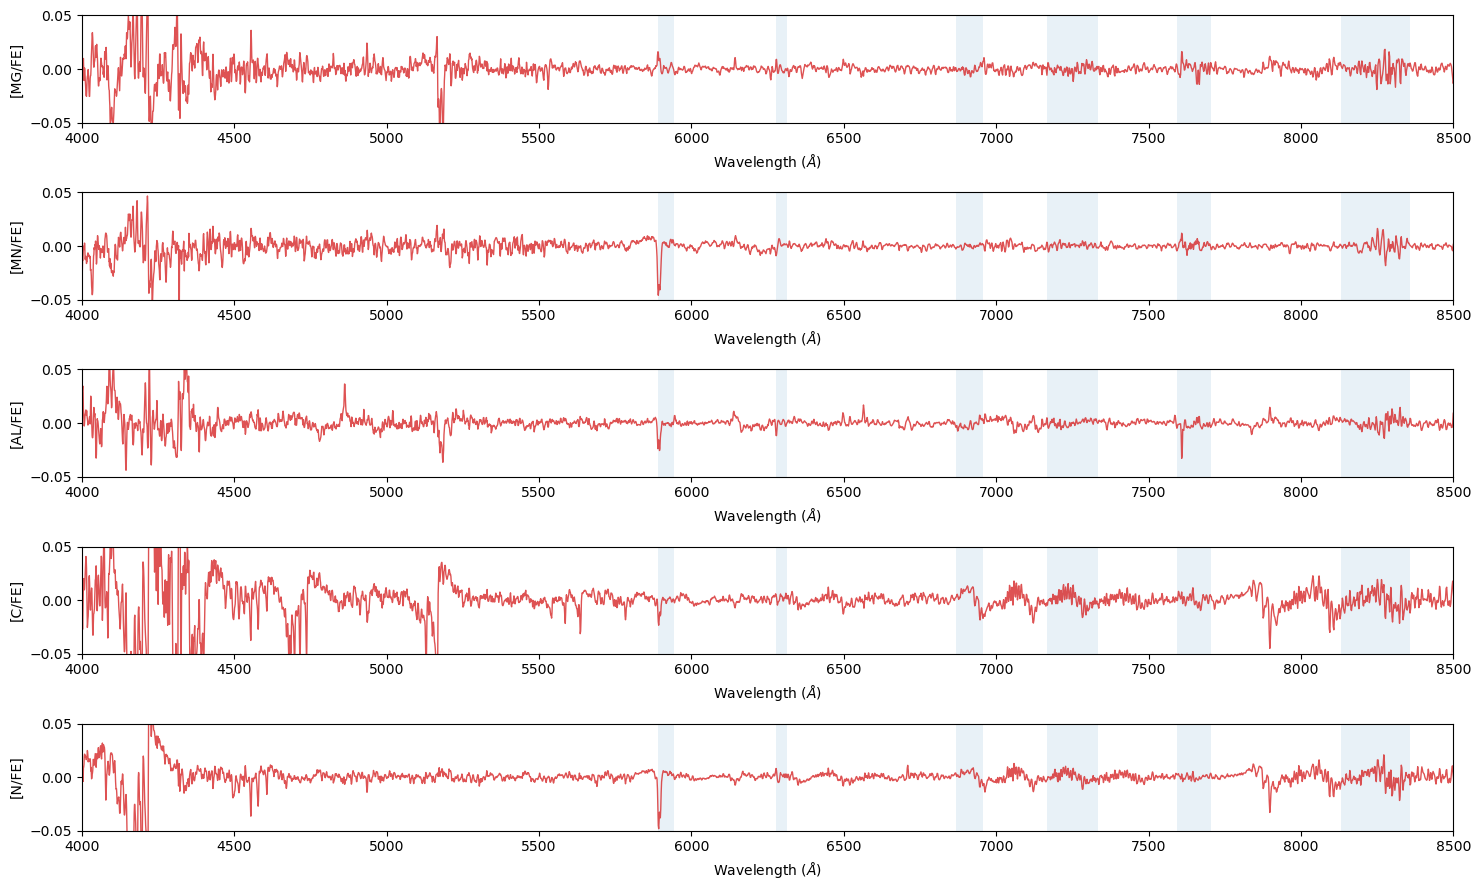

In [20]:
# --------------------------------------------------
# Plot leading theta coefficients
# --------------------------------------------------

model = full_model

telluric_file = data_path / "linelists" / "ardata.fits"

utils.plot_leading_theta_coefficients(
    model,
    LAMOST_wavelength,
    telluric_file=telluric_file
)

plt.show()

### 2.2 Absorption model

In this model, only strong absorption features associated with each chemical element are used during training.

The wavelength selection is applied through element-specific censoring masks.

In [22]:
# --------------------------------------------------
# Build censoring masks for absorption model
# --------------------------------------------------

# Elements included in the absorption model
elements = ['Mg', 'Al', 'Mn', 'C', 'N']

# Match APOGEE label names
apo_elements = [f"{elem.upper()}_FE" for elem in elements]

# Line-list files
atomic_lines_file = data_path / "linelists" / "2000vnia.book.....H_APPI_lines.txt"
cn_file = data_path / "linelists" / "CN_line_positions.txt"
ch_mgh_file = data_path / "linelists" / "CH_and_MgH_line_positions.txt"

# Dictionary storing masks
censors_absorption_model = {}

for elem, apo_elem in zip(elements, apo_elements):

    spec_mask = utils.spectral_lines_mask(
        [elem],
        sample_flux[0].shape,
        LAMOST_wavelength,
        nitrogen_carbon=True,
        atomic_lines_file=atomic_lines_file,
        CN_file=cn_file,
        CH_MgH_file=ch_mgh_file
    )

    # spectral_lines_mask returns False where lines are present
    censors_absorption_model[apo_elem] = ~spec_mask


# --------------------------------------------------
# Include Swan band for C and N
# --------------------------------------------------

swan_band = (LAMOST_wavelength >= 4000) & (LAMOST_wavelength <= 6200)

censors_absorption_model['C_FE'][swan_band] = True
censors_absorption_model['N_FE'][swan_band] = True

In [24]:
# --------------------------------------------------
# Create absorption model
# --------------------------------------------------

order = 2
absorption_labels = tuple(sample_labels.colnames)

absorption_model_file = model_path / "lamost_apogee_cannon_absorption_model"

absorption_model = tc.CannonModel(
    sample_labels,
    sample_flux,
    sample_ivar,
    vectorizer=tc.vectorizer.PolynomialVectorizer(absorption_labels, order),
    dispersion=LAMOST_wavelength
)

# Apply censoring masks
for elem in apo_elements:
    absorption_model.censors[elem] = censors_absorption_model[elem]

print("Censors:\n", absorption_model.censors)

Censors:
 {'MG_FE': array([False, False, False, ..., False, False, False]), 'AL_FE': array([False, False, False, ...,  True, False, False]), 'MN_FE': array([False, False, False, ..., False, False, False]), 'C_FE': array([ True,  True,  True, ...,  True,  True,  True]), 'N_FE': array([ True,  True,  True, ...,  True,  True,  True])}


In [26]:
# --------------------------------------------------
# Train model or load existing model
# --------------------------------------------------

model_file = absorption_model_file.with_suffix(".model")

absorption_model, absorption_model_theta, absorption_model_s = utils.train_or_load_model(
    absorption_model,
    absorption_model_file)

Existing model found: lamost_apogee_cannon_absorption_model.model


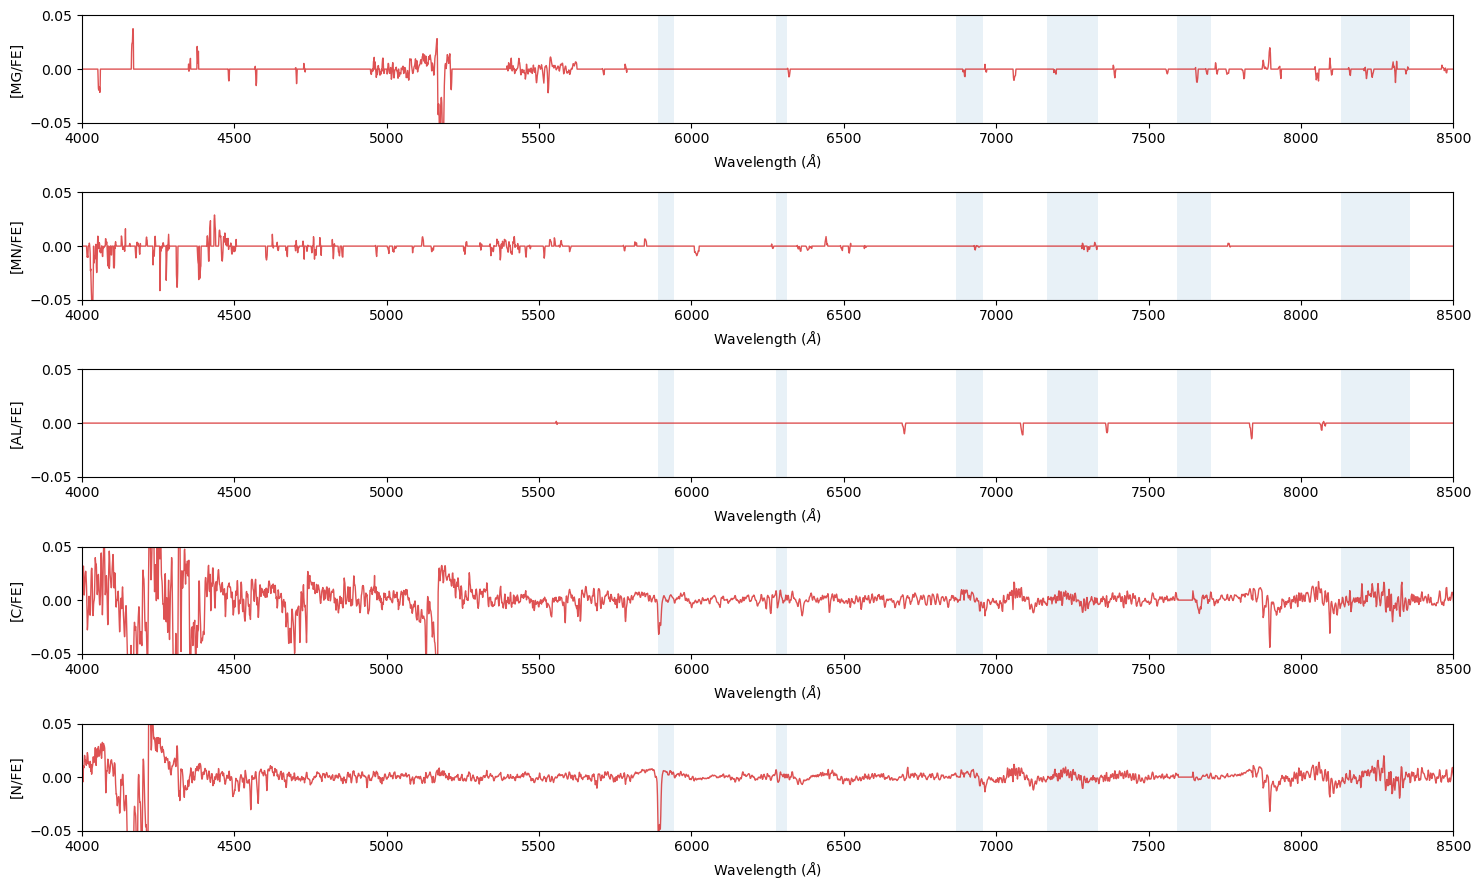

In [28]:
# --------------------------------------------------
# Plot leading theta coefficients
# --------------------------------------------------

model = absorption_model

telluric_file = data_path / "linelists" / "ardata.fits"

utils.plot_leading_theta_coefficients(
    model,
    LAMOST_wavelength,
    telluric_file=telluric_file
)

plt.show()

### 2.3 Telluric model

In this model, the inverse variance is artificially reduced within wavelength regions affected by strong telluric absorption.

This decreases the weight of contaminated pixels during training.

In [33]:
# --------------------------------------------------
# Increase spectral uncertainty in telluric regions
# --------------------------------------------------

telluric_file = data_path / "linelists" / "ardata.fits"
telluric_bands = utils.Telluric_bands(filename=telluric_file)

sample_ivar_telluric = sample_ivar.copy()

# Assigned uncertainty inside telluric regions
sigma = 999
new_ivar = 1 / sigma**2

# Build telluric mask
telluric_mask = np.zeros_like(LAMOST_wavelength, dtype=bool)

for band in telluric_bands:
    telluric_mask |= (
        (LAMOST_wavelength >= band[0]) &
        (LAMOST_wavelength <= band[1])
    )

# Apply reduced inverse variance
sample_ivar_telluric[:, telluric_mask] = new_ivar

In [35]:
# --------------------------------------------------
# Create telluric model
# --------------------------------------------------

order = 2
telluric_labels = tuple(sample_labels.colnames)

telluric_model_file = model_path / "lamost_apogee_cannon_telluric_model"

telluric_model = tc.CannonModel(
    sample_labels,
    sample_flux,
    sample_ivar_telluric,
    vectorizer=tc.vectorizer.PolynomialVectorizer(telluric_labels, order),
    dispersion=LAMOST_wavelength)

In [37]:
# --------------------------------------------------
# Train or load telluric model
# --------------------------------------------------

telluric_model, telluric_model_theta, telluric_model_s = utils.train_or_load_model(
    telluric_model,
    telluric_model_file
)

Existing model found: lamost_apogee_cannon_telluric_model.model


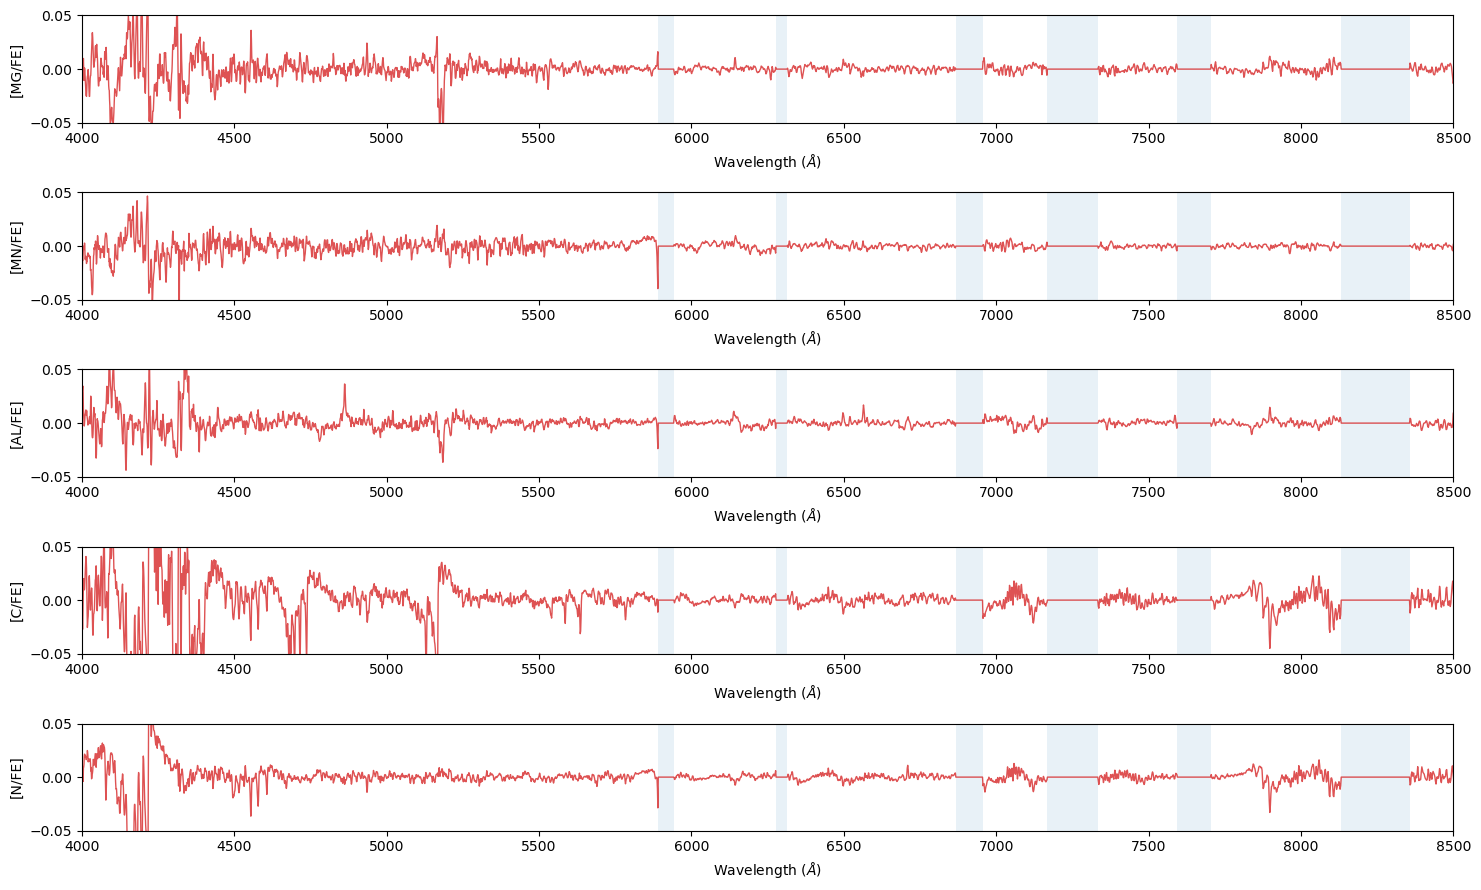

In [39]:
# --------------------------------------------------
# Plot leading theta coefficients
# --------------------------------------------------

model = telluric_model

telluric_file = data_path / "linelists" / "ardata.fits"

utils.plot_leading_theta_coefficients(
    model,
    LAMOST_wavelength,
    telluric_file=telluric_file
)

plt.show()

### 2.4 Combined model

This model combines both strategies:

- reduced inverse variance in telluric regions  
- element-specific wavelength censoring based on strong absorption features

In [42]:
# --------------------------------------------------
# Reuse absorption masks for combined model (as in the Absorption model)
# --------------------------------------------------

censors_combined_model = censors_absorption_model.copy()

In [45]:
# --------------------------------------------------
# Create combined model
# --------------------------------------------------

order = 2
combined_labels = tuple(sample_labels.colnames)

combined_model_file = model_path / "lamost_apogee_cannon_combined_model"

combined_model = tc.CannonModel(
    sample_labels,
    sample_flux,
    sample_ivar_telluric,
    vectorizer=tc.vectorizer.PolynomialVectorizer(combined_labels, order),
    dispersion=LAMOST_wavelength
)

# Apply absorption censors
for elem in apo_elements:
    combined_model.censors[elem] = censors_combined_model[elem]

print("Censors:\n", combined_model.censors)

Censors:
 {'MG_FE': array([False, False, False, ..., False, False, False]), 'AL_FE': array([False, False, False, ...,  True, False, False]), 'MN_FE': array([False, False, False, ..., False, False, False]), 'C_FE': array([ True,  True,  True, ...,  True,  True,  True]), 'N_FE': array([ True,  True,  True, ...,  True,  True,  True])}


In [47]:
# --------------------------------------------------
# Train or load combined model
# --------------------------------------------------

combined_model, combined_model_theta, combined_model_s = utils.train_or_load_model(
    combined_model,
    combined_model_file)

Existing model found: lamost_apogee_cannon_combined_model.model


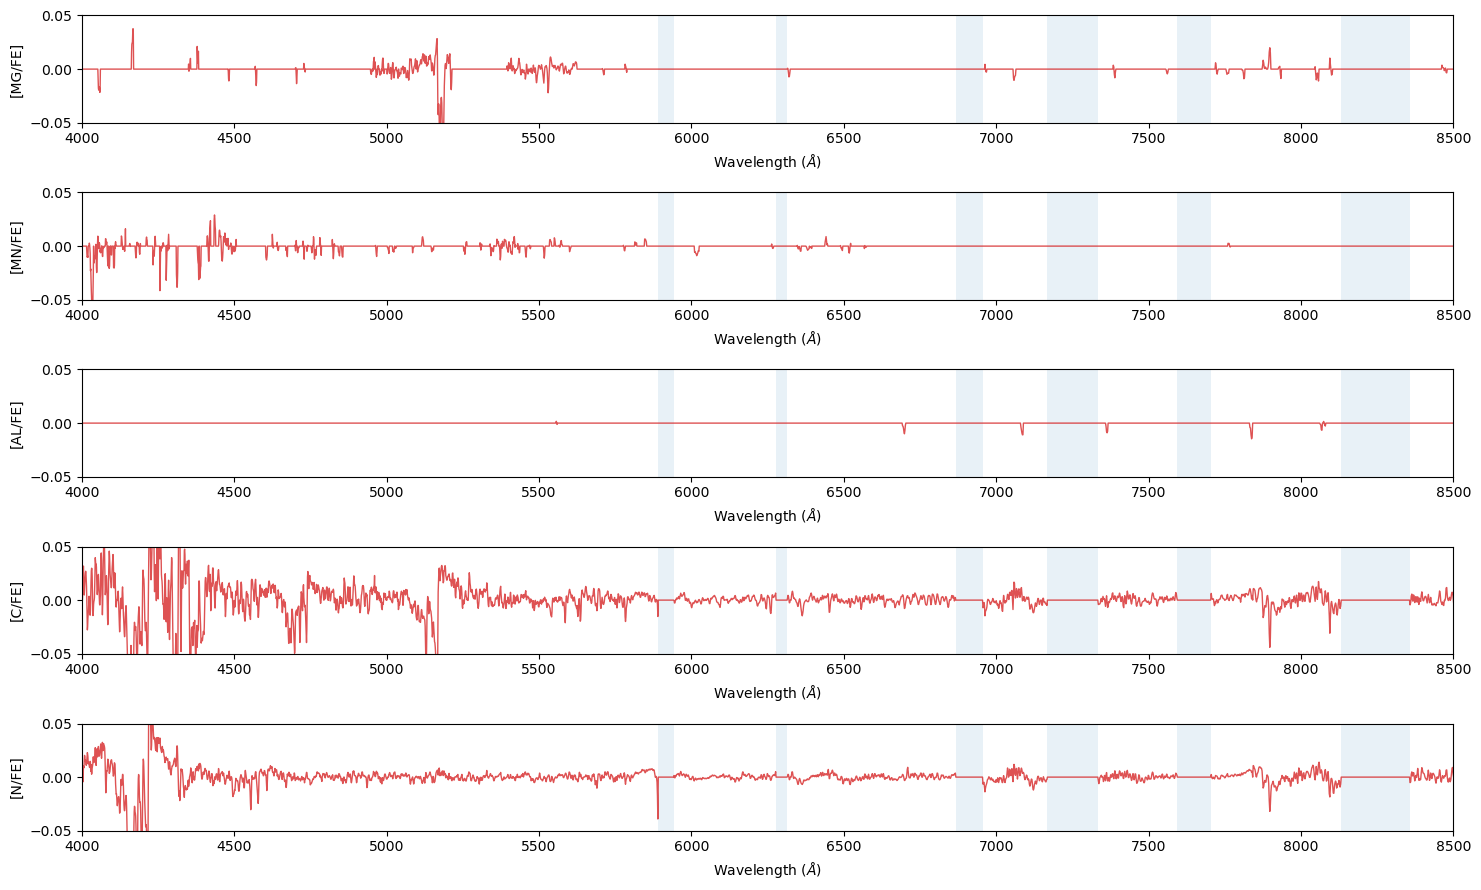

In [51]:
# --------------------------------------------------
# Plot leading theta coefficients
# --------------------------------------------------

model = combined_model

telluric_file = data_path / "linelists" / "ardata.fits"

utils.plot_leading_theta_coefficients(
    model,
    LAMOST_wavelength,
    telluric_file=telluric_file
)

plt.show()

### Plotting scatters

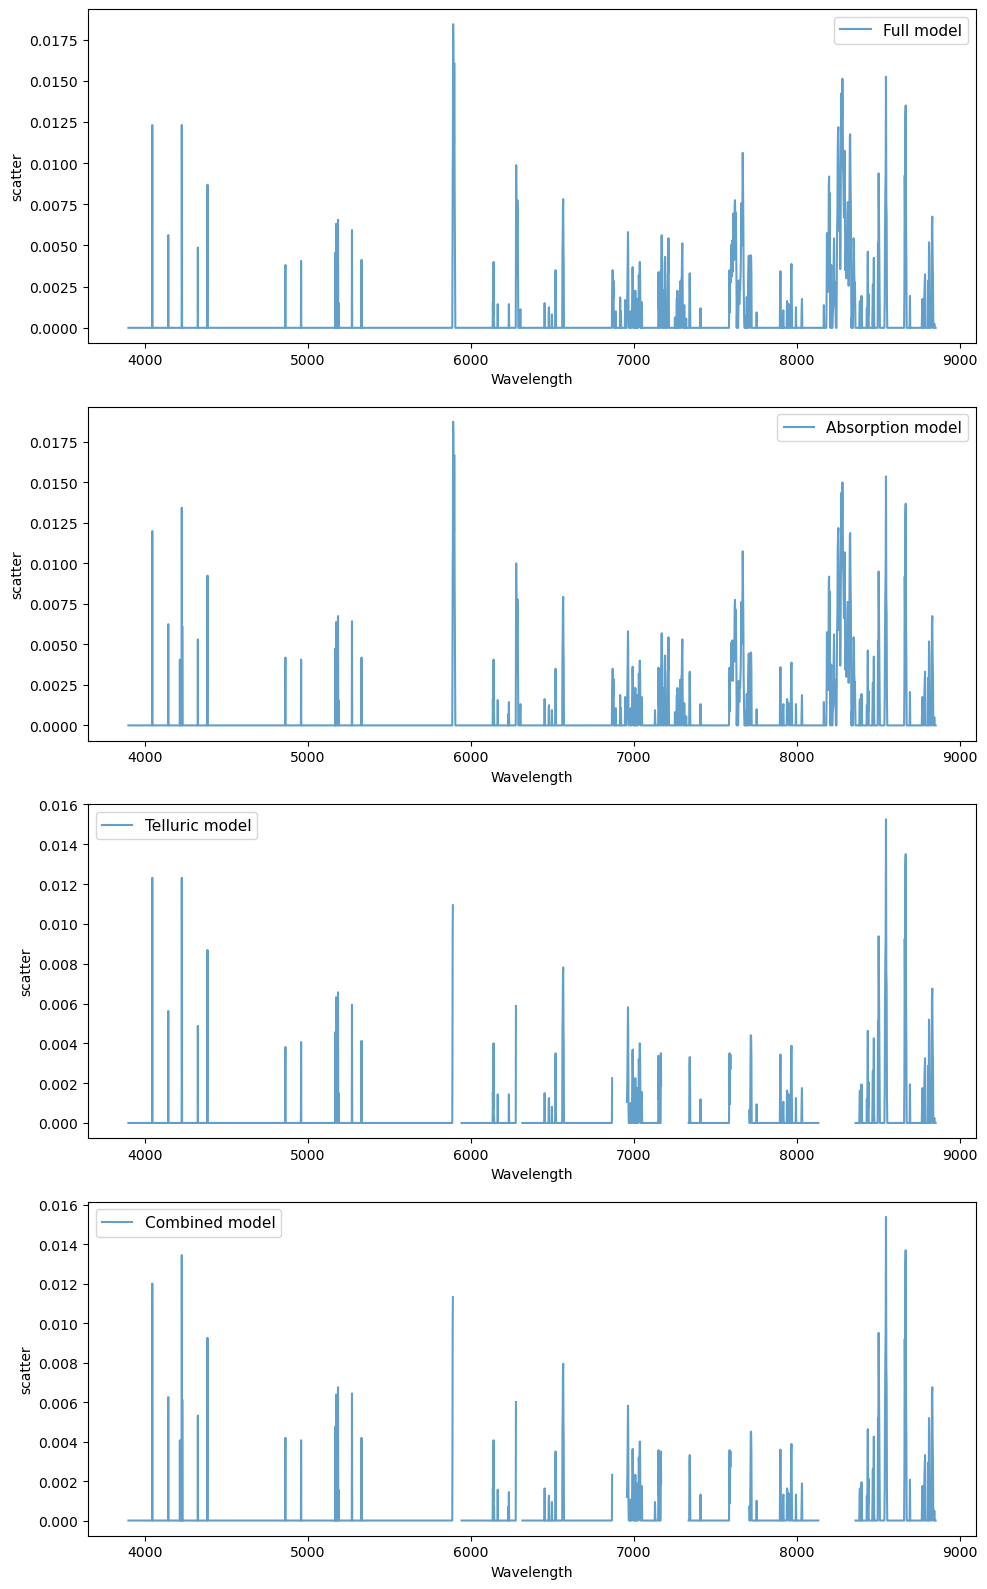

In [56]:
models = [full_model, absorption_model,
          telluric_model,combined_model]
model_names = ['Full model',
               'Absorption model',
               'Telluric model',
               'Combined model']
ylabel = 'scatter'

fig, axs = plt.subplots(4, 1 , figsize=(10, 16))

for m in range(len(models)):
    ax =axs[m]
    ax.plot(LAMOST_wavelength,
            models[m].s2**0.5,
            c='C0', label=f'{model_names[m]}', alpha=0.7)
    ax.set_xlabel(f'Wavelength')
    ax.set_ylabel(ylabel)
    ax.legend(loc='best', fontsize=11, frameon=True)
plt.tight_layout()
plt.show()

## Cross-validation using LAMOST spectra

For doing the cross-validation we will adopt the take-25%-out test, where the full set is divided into four groups, each group is excluded in turn while training on the remaining three, and the trained model is then applied to the left-out group. At the end of this process, every reference object has a new set of labels inferred from a model in which it was not included.

In [8]:
# we will use the KFold method to fold the sample in 4 groups
from sklearn.model_selection import KFold
kf = KFold(n_splits=4, shuffle=True, random_state=22)

outfiles_data_path = Path("output_files/")
outfiles_data_path.mkdir(exist_ok=True)

In [15]:
# Full-spectrum model validation

# Dictionary for saving predictions:
crossval_results = {}
val_idxs = {}  #for the tested stars
metadata_results= {}

## Defining some parameters
val_model_name = 'full_model' 
val_model_labels = sample_labels
val_model_label_names = tuple(sample_labels.colnames)
val_sample_flux = sample_flux
val_sample_ivar = sample_ivar
val_wavelength = LAMOST_wavelength


for i, (train_idx, test_idx) in enumerate(kf.split(val_model_labels)):
    print(f'Fold {i+1}')

    val_model_file = f'crossvalidaiton_model{i}_{val_model_name}'

    #defining each training and testing sets
    val_labels_train,val_labels_test = val_model_labels[train_idx] , val_model_labels[test_idx]
    val_sample_flux_train , val_sample_flux_test =  val_sample_flux[train_idx], val_sample_flux[test_idx]
    val_sample_ivar_train , val_sample_ivar_test =  val_sample_ivar[train_idx], val_sample_ivar[test_idx]

    # Creating the model
    val_model = tc.CannonModel(val_labels_train, 
                                val_sample_flux_train, 
                                val_sample_ivar_train,
                                vectorizer=tc.vectorizer.PolynomialVectorizer(val_model_label_names, 2), #order=2
                                dispersion=val_wavelength)

    print(val_model_file)

    # We train the model
    try:
        val_model = tc.CannonModel.read(val_model_file+'.model')
        val_model_theta, val_model_s = val_model.theta, val_model.s2
        print('We have already a model, lets use that one. Model: ',i)
    except:
        # There is no CannonModel available yet
        # Let's setup the Cannon model.
        print('Training The Cannon. Model: ',i)
        val_model_theta, val_model_s, _ = val_model.train()  
        # Let's save the result
        val_model.write(val_model_file+'.model',overwrite=True)

    ## --- TESTING ---
    print('##########################################')
    print('##########################################')
    print(f'TESTING {val_model_name}_{i} :')
    params = val_model.test(val_sample_flux_test,val_sample_ivar_test)
    predicted_labels_val_model, cov_val_model, metadata_val_model = params

    crossval_results[f'{val_model_name}_{i}'] = predicted_labels_val_model
    metadata_results[f'{val_model_name}_{i}'] = metadata_val_model
    val_idxs[f'{val_model_name}_{i}'] = test_idx

crossval_results_full =  crossval_results.copy()
metadata_results_full = metadata_results.copy()
#censors_full_model = censors_dic.copy()  no censors for this model

# Displaying the dictionaries
crossval_table_0 = Table({label: col for label, col in zip(['Teff','logg','vmic','Ak','l_feh','l_mg','l_mn','l_al','l_c','l_n'], crossval_results[f'{val_model_name}_0'].T)})
crossval_table_1 = Table({label: col for label, col in zip(['Teff','logg','vmic','Ak','l_feh','l_mg','l_mn','l_al','l_c','l_n'], crossval_results[f'{val_model_name}_1'].T)})
crossval_table_2 = Table({label: col for label, col in zip(['Teff','logg','vmic','Ak','l_feh','l_mg','l_mn','l_al','l_c','l_n'], crossval_results[f'{val_model_name}_2'].T)})
crossval_table_3 = Table({label: col for label, col in zip(['Teff','logg','vmic','Ak','l_feh','l_mg','l_mn','l_al','l_c','l_n'], crossval_results[f'{val_model_name}_3'].T)})

crossval_table = vstack([crossval_table_0, crossval_table_1,crossval_table_2, crossval_table_3])

val_idxs_total = np.concatenate((val_idxs[f'{val_model_name}_0'],
                                          val_idxs[f'{val_model_name}_1'],
                                          val_idxs[f'{val_model_name}_2'],
                                          val_idxs[f'{val_model_name}_3']))
crossval_table['idx'] =  val_idxs_total

#saving the table with predicted labels for this valilidation process
crossval_table.write(f'output_files/crossvalidation/crossval_table_{val_model_name}_{len(crossval_table)}.csv', format='ascii.csv',overwrite=True)

Fold 1


stty: 'standard input': Inappropriate ioctl for device2026-02-16 11:11:49,988 [DEBUG] Couldn't get screen size. Progressbar may look odd.
2026-02-16 11:11:49,989 [INFO] Running test step on 3853 spectra



crossvalidaiton_model0_full_model
We have already a model, lets use that one. Model:  0
##########################################
##########################################
TESTING full_model_0 :
[=====================================================================================================] 100% (549s)                               
Fold 2


2026-02-16 11:21:00,003 [DEBUG] Couldn't get screen size. Progressbar may look odd.
stty: 'standard input': Inappropriate ioctl for device
2026-02-16 11:21:00,004 [INFO] Running test step on 3853 spectra


crossvalidaiton_model1_full_model
We have already a model, lets use that one. Model:  1
##########################################
##########################################
TESTING full_model_1 :
[=====================================================================================================] 100% (695s)                               
Fold 3


stty: 'standard input'2026-02-16 11:32:35,800 [DEBUG] Couldn't get screen size. Progressbar may look odd.
2026-02-16 11:32:35,801 [INFO] Running test step on 3852 spectra
: Inappropriate ioctl for device


crossvalidaiton_model2_full_model
We have already a model, lets use that one. Model:  2
##########################################
##########################################
TESTING full_model_2 :
[=====================================================================================================] 100% (571s)                               
Fold 4


2026-02-16 11:42:08,005 [DEBUG] Couldn't get screen size. Progressbar may look odd.
stty: 'standard input': Inappropriate ioctl for device
2026-02-16 11:42:08,007 [INFO] Running test step on 3852 spectra


crossvalidaiton_model3_full_model
We have already a model, lets use that one. Model:  3
##########################################
##########################################
TESTING full_model_3 :
[=====================================================================================================] 100% (555s)                               


In [48]:
chi_sq_list = []
r_chi_sq_list = []
for F in range(0,4):
    met = metadata_results_full[f'full_model_{F}']
    for i in range(len(met)):
        chi_sq_list.append(met[i]['chi_sq'])
        r_chi_sq_list.append(met[i]['r_chi_sq'])

crossval_table_full_model = Table.read(f'output_files/crossvalidation/crossval_table_full_model_15410.csv')
crossval_table_full_model['chi_sq'] = chi_sq_list
crossval_table_full_model['r_chi_sq'] = r_chi_sq_list
crossval_table_full_model.write(f'output_files/crossvalidation/crossval_table_{val_model_name}_{len(crossval_table)}.csv', format='ascii.csv',overwrite=True)

In [10]:
# Absorption model validation: Chatgpt version
## Defining some parameters
val_model_name = 'absorption_model' 
val_model_labels = sample_labels
val_model_label_names = tuple(sample_labels.colnames)
val_sample_flux = sample_flux
val_sample_ivar = sample_ivar
val_wavelength = LAMOST_wavelength

# --- PRECOMPUTE CENSORING MASKS (ONLY ONCE) ---

elements = ['Mg','Al','Mn','C','N']
apo_elements = [elem.upper() + '_FE' for elem in elements]

censors_dic = {}

for j, elem in enumerate(elements):
    spec_mask = utils.spectral_lines_mask(
        [elem],
        val_sample_flux[0].shape,
        val_wavelength,
        nitrogen_carbon=True,
        atomic_lines_file=f'{data_path}/linelists/2000vnia.book.....H_APPI_lines.txt',
        CN_file=f'{data_path}/linelists/CN_line_positions.txt',
        CH_MgH_file=f'{data_path}/linelists/CH_and_MgH_line_positions.txt'
    )

    spec_mask = ~spec_mask
    censors_dic[apo_elements[j]] = spec_mask

# Swan band (apply once)
swan_mask = (val_wavelength >= 4000) & (val_wavelength <= 6200)
censors_dic['C_FE'][swan_mask] = True
censors_dic['N_FE'][swan_mask] = True


# --- CROSSVALIDATION LOOP ---

tables = []
idxs_all = []

for i, (train_idx, test_idx) in enumerate(kf.split(val_model_labels)):
    print(f'Fold {i+1}')

    # Split
    val_labels_train = val_model_labels[train_idx]
    val_sample_flux_train = val_sample_flux[train_idx]
    val_sample_ivar_train = val_sample_ivar[train_idx]

    val_sample_flux_test = val_sample_flux[test_idx]
    val_sample_ivar_test = val_sample_ivar[test_idx]

    # Model
    val_model = tc.CannonModel(
        val_labels_train,
        val_sample_flux_train,
        val_sample_ivar_train,
        vectorizer=tc.vectorizer.PolynomialVectorizer(val_model_label_names, 2),
        dispersion=val_wavelength
    )

    # Apply censors
    for elem in apo_elements:
        val_model.censors[elem] = censors_dic[elem]

    # Train (no disk writing)
    print(f'Training model {i}')
    val_model.train()

    # Test
    print(f'Testing model {i}')
    predicted_labels, _, _ = val_model.test(
        val_sample_flux_test,
        val_sample_ivar_test
    )

    # Build table directly
    fold_table = Table(
        {label: col for label, col in zip(
            ['Teff','logg','vmic','Ak','l_feh','l_mg','l_mn','l_al','l_c','l_n'],
            predicted_labels.T
        )}
    )

    fold_table['idx'] = test_idx

    tables.append(fold_table)
    idxs_all.append(test_idx)


# --- FINAL TABLE ---
crossval_table = vstack(tables)

crossval_table.write(
    f'output_files/crossvalidation/crossval_table_{val_model_name}_{len(crossval_table)}.csv',
    format='ascii.csv',
    overwrite=True
)


Fold 1


2026-02-13 14:39:43,017 [INFO] Training 10-label CannonModel with 11557 stars and 3559 pixels/star
stty: 'standard input'2026-02-13 14:39:43,022 [DEBUG] Couldn't get screen size. Progressbar may look odd.


Training model 0


: Inappropriate ioctl for device


[===                                                                                                 ]   3% (113/3559)                          

...

2026-02-13 20:21:14,305 [WARNING] Optimization warning (l_bfgs_b): ABNORMAL: 


[========================================================================================            ]  87% (3108/3559; ~50m until finished)

2026-02-13 20:25:20,427 [WARNING] Optimization warning (l_bfgs_b): ABNORMAL: 


[========================================================================================            ]  87% (3111/3559; ~50m until finished)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [50]:
# Absorptiom model validation

# Dictionary for saving predictions:
crossval_results = {}
val_idxs = {}  #for the tested stars
metadata_results = {}

## Defining some parameters
val_model_name = 'absorption_model' 
val_model_labels = sample_labels
val_model_label_names = tuple(sample_labels.colnames)
val_sample_flux = sample_flux
val_sample_ivar = sample_ivar
val_wavelength = LAMOST_wavelength


# --- PRECOMPUTE CENSORING MASKS (ONLY ONCE) ---
elements = ['Mg','Al','Mn','C','N']
apo_elements = [elem.upper() + '_FE' for elem in elements]

censors_dic = {}

for j, elem in enumerate(elements):
    spec_mask = utils.spectral_lines_mask([elem],
                                          val_sample_flux[0].shape,
                                          val_wavelength,
                                          nitrogen_carbon=True,
                                          atomic_lines_file=f'{data_path}/linelists/2000vnia.book.....H_APPI_lines.txt',
                                          CN_file=f'{data_path}/linelists/CN_line_positions.txt',
                                          CH_MgH_file=f'{data_path}/linelists/CH_and_MgH_line_positions.txt')

    spec_mask = ~spec_mask
    censors_dic[apo_elements[j]] = spec_mask

# Swan band (apply once)
swan_mask = (val_wavelength >= 4000) & (val_wavelength <= 6200)
censors_dic['C_FE'][swan_mask] = True
censors_dic['N_FE'][swan_mask] = True




for i, (train_idx, test_idx) in enumerate(kf.split(val_model_labels)):
    print(f'Fold {i+1}')

    val_model_file = f'crossvalidaiton_model{i}_{val_model_name}'

    ## --- DEFINING TRAINING AND TESTING SETS ---
    val_labels_train,val_labels_test = val_model_labels[train_idx] , val_model_labels[test_idx]
    val_sample_flux_train , val_sample_flux_test =  val_sample_flux[train_idx], val_sample_flux[test_idx]
    val_sample_ivar_train , val_sample_ivar_test =  val_sample_ivar[train_idx], val_sample_ivar[test_idx]

    
    ### --- CENSORING MASKS  ---
    # List of elements to be considered:
    #elements = ['Mg','Al','Mn','C','N']
    ## Uppercasing and appending '_FE' to match APOGEE label names:
    #apo_elements = [elem.upper() + '_FE' for elem in elements] 
    ## Dictionary with the masks:
    #censors_dic = dict()
    #for j,elem in enumerate(elements):
    #    spec_mask = utils.spectral_lines_mask([elem], 
    #                                    val_sample_flux[0].shape, 
    #                                    val_wavelength,
    #                                    nitrogen_carbon=True,
    #                                    atomic_lines_file = f'{data_path}/linelists/2000vnia.book.....H_APPI_lines.txt',
    #                                    CN_file = f'{data_path}/linelists/CN_line_positions.txt',
    #                                    CH_MgH_file = f'{data_path}/linelists/CH_and_MgH_line_positions.txt')
    #    # Because spec_mask is False where elements are found, we need to invert
    #    spec_mask = ~spec_mask # (True where elements are found)    
    #    censors_dic[apo_elements[j]] = spec_mask
    ## For the Swan band
    #for k,l in enumerate(val_wavelength):
     #   if l >= 4000 and l <= 6200:
     #       censors_dic['C_FE'][k] = True
     #       censors_dic['N_FE'][k] = True


    
    ## --- SETTING UP THE MODELS --- 
    val_model = tc.CannonModel(val_labels_train, 
                                val_sample_flux_train, 
                                val_sample_ivar_train,
                                vectorizer=tc.vectorizer.PolynomialVectorizer(val_model_label_names, 2), #order=2
                                dispersion=val_wavelength)
    # Applying censoring masks
    for elem in apo_elements:
        val_model.censors[elem] = censors_dic[elem]

    

    ## --- TRAINING THE MODELS ---
    try:
        val_model = tc.CannonModel.read(val_model_file+'.model')
        val_model_theta, val_model_s = val_model.theta, val_model.s2
        print('We have already a model, lets use that one. Model: ',i)
    except:
        # There is no CannonModel available yet
        # Let's setup the Cannon model.
        print('Training The Cannon. Model: ',i)
        val_model_theta, val_model_s, val_model_metadata = val_model.train()  
        # Let's save the result
        val_model.write(val_model_file+'.model',overwrite=True)

    ## --- TESTING THE MODELS ---
    print('##########################################')
    print('##########################################')
    print(f'TESTING {val_model_name}_{i} :')
    params = val_model.test(val_sample_flux_test,val_sample_ivar_test)
    predicted_labels_val_model, cov_val_model, metadata_val_model = params

    crossval_results[f'{val_model_name}_{i}'] = predicted_labels_val_model
    metadata_results[f'{val_model_name}_{i}'] = metadata_val_model
    val_idxs[f'{val_model_name}_{i}'] = test_idx

crossval_results_absorption =  crossval_results.copy()
metadata_results_absorption = metadata_results.copy()
censors_absorption_model = censors_dic.copy()

# Displaying the dictionaries
crossval_table_0 = Table({label: col for label, col in zip(['Teff','logg','vmic','Ak','l_feh','l_mg','l_mn','l_al','l_c','l_n'], crossval_results[f'{val_model_name}_0'].T)})
crossval_table_1 = Table({label: col for label, col in zip(['Teff','logg','vmic','Ak','l_feh','l_mg','l_mn','l_al','l_c','l_n'], crossval_results[f'{val_model_name}_1'].T)})
crossval_table_2 = Table({label: col for label, col in zip(['Teff','logg','vmic','Ak','l_feh','l_mg','l_mn','l_al','l_c','l_n'], crossval_results[f'{val_model_name}_2'].T)})
crossval_table_3 = Table({label: col for label, col in zip(['Teff','logg','vmic','Ak','l_feh','l_mg','l_mn','l_al','l_c','l_n'], crossval_results[f'{val_model_name}_3'].T)})

crossval_table = vstack([crossval_table_0, crossval_table_1,crossval_table_2, crossval_table_3])

val_idxs_total = np.concatenate((val_idxs[f'{val_model_name}_0'],
                                          val_idxs[f'{val_model_name}_1'],
                                          val_idxs[f'{val_model_name}_2'],
                                          val_idxs[f'{val_model_name}_3']))
crossval_table['idx'] = val_idxs_total

#keeping chi2 values
chi_sq_list = []
r_chi_sq_list = []
for F in range(0,4):
    met = metadata_results[f'{val_model_name}_{F}']
    for S in range(len(met)):
        chi_sq_list.append(met[S]['chi_sq'])
        r_chi_sq_list.append(met[S]['r_chi_sq'])

crossval_table['chi_sq'] = chi_sq_list
crossval_table['r_chi_sq'] = r_chi_sq_list


#saving the table with predicted labels for this valilidation process
crossval_table.write(f'output_files/crossvalidation/crossval_table_{val_model_name}_{len(crossval_table)}.csv', format='ascii.csv',overwrite=True)

Fold 1


2026-02-16 12:35:03,528 [INFO] Training 10-label CannonModel with 11557 stars and 3559 pixels/star
stty: 'standard input': Inappropriate ioctl for device2026-02-16 12:35:03,533 [DEBUG] Couldn't get screen size. Progressbar may look odd.


Training The Cannon. Model:  0


[===                                                                                                 ]   3% (113/3559)                          

2026-02-16 12:43:32,202 [WARNING] Optimization warning (l_bfgs_b): ABNORMAL: 


...

[==================================================================================================  ]  97% (3449/3559; ~13m until finished)

2026-02-17 15:24:39,719 [WARNING] Optimization warning (l_bfgs_b): ABNORMAL: 


[=====================================================================================================] 100% (25602s)                             


stty: 'standard input'2026-02-17 15:38:22,961 [DEBUG] Couldn't get screen size. Progressbar may look odd.
: Inappropriate ioctl for device
2026-02-17 15:38:22,963 [INFO] Running test step on 3852 spectra


##########################################
##########################################
TESTING absorption_model_3 :
[=====================================================================================================] 100% (463s)                               


In [51]:
crossval_table

Teff,logg,vmic,Ak,l_feh,l_mg,l_mn,l_al,l_c,l_n,idx,chi_sq,r_chi_sq
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64
5001.189325301722,3.243635153664431,0.38418879309441256,0.08376714225721102,-0.17261617059822493,0.05695432594503065,-0.024954645619377883,-0.06451517109218485,-0.07528370543393725,0.1391348441932153,0,4585.290552368522,1.2923592312199894
4823.040174037094,2.4773426019103817,1.5500359661390843,0.053724933906745445,-0.07590402404632651,0.026413268436370416,0.00010340368850668413,0.0808767273396579,-0.12928891859523223,0.2406306637269669,2,13538.85303669449,3.815911227929676
4221.025135521128,1.1443139610008106,1.7126803870706329,0.10065608610042383,-1.000210949197263,0.10972662693682485,-0.23207915948301813,-0.24273056739845167,-0.25542432722243513,0.26634720643397847,4,1667.1981693069088,0.46989801840668227
5224.134508783771,3.3472753336463716,1.158081534394114,0.17004146332575287,-0.43928015148192323,0.12020125694164585,-0.06386310924109616,0.07012699413780255,0.035586788579080667,-0.08063919308183282,11,2637.2388956009913,0.7433029581738984
4563.882697322325,2.0875340290991975,1.450302494910207,0.16473997020970282,-0.2930831800099905,0.07374178738841856,-0.11675325869810455,0.09751774391089202,-0.15993535257417293,0.1176625502023811,18,10921.338136416192,3.0781674567125683
4913.5837359985435,2.3897596049200023,1.8761874685881148,0.11063297258236351,-0.4748345053174004,0.3322487060362008,-0.20174401702735478,0.251213389020456,0.028067322341709763,-0.029773551819407384,20,5419.040339046226,1.5273507156274595
4613.630417048564,2.6631155736798466,0.9854609338765457,0.20185714016113138,0.11395344750758785,0.07493015968876705,-0.004656687146579928,0.14431446389090388,-0.040318042287509646,0.12301972877362635,24,9646.79482227945,2.718938788692066
4969.618088414287,3.435632362073109,0.8193624532781023,0.2058622866887641,0.0799541546588422,0.04984765913684461,0.045158339620459426,0.036950813948247965,0.01234244299592874,0.1301355600108476,27,3055.188856835014,0.8613444761305368
4944.691402904668,2.0680785071667045,1.8090714507175767,0.12453024791678569,-0.7261529105987654,0.46645193324182616,-0.31317977838926003,0.39239647417004103,0.1286759317354086,-0.0692878727865871,28,2895.476004372006,0.8160868107023693


In [56]:
# Combined model validation

# Dictionary for saving predictions:
crossval_results = {}
metadata_results = {}
val_idxs = {}  #for the tested stars

## Defining some parameters
val_model_name = 'combined_model' 
val_model_labels = sample_labels
val_model_label_names = tuple(sample_labels.colnames)
val_sample_flux = sample_flux
val_sample_ivar = sample_ivar_telluric
val_wavelength = LAMOST_wavelength


# --- PRECOMPUTE CENSORING MASKS (ONLY ONCE) ---
elements = ['Mg','Al','Mn','C','N']
apo_elements = [elem.upper() + '_FE' for elem in elements]
censors_dic = {}
for j, elem in enumerate(elements):
    spec_mask = utils.spectral_lines_mask([elem],
                                          val_sample_flux[0].shape,
                                          val_wavelength,
                                          nitrogen_carbon=True,
                                          atomic_lines_file=f'{data_path}/linelists/2000vnia.book.....H_APPI_lines.txt',
                                          CN_file=f'{data_path}/linelists/CN_line_positions.txt',
                                          CH_MgH_file=f'{data_path}/linelists/CH_and_MgH_line_positions.txt')

    spec_mask = ~spec_mask
    censors_dic[apo_elements[j]] = spec_mask

# Swan band (apply once)
swan_mask = (val_wavelength >= 4000) & (val_wavelength <= 6200)
censors_dic['C_FE'][swan_mask] = True
censors_dic['N_FE'][swan_mask] = True



for i, (train_idx, test_idx) in enumerate(kf.split(val_model_labels)):
    print(f'Fold {i+1}')

    val_model_file = f'crossvalidaiton_model{i}_{val_model_name}'

    ## --- DEFINING TRAINING AND TESTING SETS ---
    val_labels_train,val_labels_test = val_model_labels[train_idx] , val_model_labels[test_idx]
    val_sample_flux_train , val_sample_flux_test =  val_sample_flux[train_idx], val_sample_flux[test_idx]
    val_sample_ivar_train , val_sample_ivar_test =  val_sample_ivar[train_idx], val_sample_ivar[test_idx]
    

    ### --- CENSORING MASKS  ---
    ## List of elements to be considered:
    #elements = ['Mg','Al','Mn','C','N']
    ## Uppercasing and appending '_FE' to match APOGEE label names:
    #apo_elements = [elem.upper() + '_FE' for elem in elements] 
    ## Dictionary with the masks:
    #censors_dic = dict()
    #for j,elem in enumerate(elements):
    #    spec_mask = utils.spectral_lines_mask([elem], 
    #                                    val_sample_flux[0].shape, 
    #                                    val_wavelength,
    #                                    nitrogen_carbon=True,
    #                                    atomic_lines_file = f'{data_path}/linelists/2000vnia.book.....H_APPI_lines.txt',
    #                                    CN_file = f'{data_path}/linelists/CN_line_positions.txt',
    #                                    CH_MgH_file = f'{data_path}/linelists/CH_and_MgH_line_positions.txt')
    #    # Because spec_mask is False where elements are found, we need to invert
    #    spec_mask = ~spec_mask # (True where elements are found)    
    #    censors_dic[apo_elements[j]] = spec_mask
    ## For the Swan band
    #for k,l in enumerate(val_wavelength):
    #    if l >= 4000 and l <= 6200:
    #        censors_dic['C_FE'][k] = True
    #        censors_dic['N_FE'][k] = True


    
    ## --- SETTING UP THE MODEL ---
    val_model = tc.CannonModel(val_labels_train, 
                                val_sample_flux_train, 
                                val_sample_ivar_train,
                                vectorizer=tc.vectorizer.PolynomialVectorizer(val_model_label_names, 2), #order=2
                                dispersion=val_wavelength)
    # Applying censoring masks
    for elem in apo_elements:
        val_model.censors[elem] = censors_dic[elem]


    
    ## --- TRAINING THE MODELS ---
    try:
        val_model = tc.CannonModel.read(val_model_file+'.model')
        val_model_theta, val_model_s = val_model.theta, val_model.s2
        print('We have already a model, lets use that one. Model: ',i)
    except:
        # There is no CannonModel available yet
        # Let's setup the Cannon model.
        print('Training The Cannon. Model: ',i)
        val_model_theta, val_model_s, val_model_metadata = val_model.train()  
        # Let's save the result
        val_model.write(val_model_file+'.model',overwrite=True)

    ## --- TESTING THE MODELS ---
    print('##########################################')
    print('##########################################')
    print(f'TESTING {val_model_name}_{i} :')
    params = val_model.test(val_sample_flux_test,val_sample_ivar_test)
    predicted_labels_val_model, cov_val_model, metadata_val_model = params

    crossval_results[f'{val_model_name}_{i}'] = predicted_labels_val_model
    metadata_results[f'{val_model_name}_{i}'] = metadata_val_model
    val_idxs[f'{val_model_name}_{i}'] = test_idx

crossval_results_combined =  crossval_results.copy()
metadata_results_combined = metadata_results.copy()
censors_combined_model = censors_dic.copy()

#--------------
# because the keys were not well wrote
# New names of the dic keys
#new_keys = [f'{val_model_name}_0',
#           f'{val_model_name}_1',
#          f'{val_model_name}_2',
#          f'{val_model_name}_3']

# new dic with the new names
#crossval_resultss = {new_key: value for new_key, value in zip(new_keys, crossval_results.values())}
#--------------

# Displaying the dictionaries
crossval_table_0 = Table({label: col for label, col in zip(['Teff','logg','vmic','Ak','l_feh','l_mg','l_mn','l_al','l_c','l_n'], crossval_results[f'{val_model_name}_0'].T)})
crossval_table_1 = Table({label: col for label, col in zip(['Teff','logg','vmic','Ak','l_feh','l_mg','l_mn','l_al','l_c','l_n'], crossval_results[f'{val_model_name}_1'].T)})
crossval_table_2 = Table({label: col for label, col in zip(['Teff','logg','vmic','Ak','l_feh','l_mg','l_mn','l_al','l_c','l_n'], crossval_results[f'{val_model_name}_2'].T)})
crossval_table_3 = Table({label: col for label, col in zip(['Teff','logg','vmic','Ak','l_feh','l_mg','l_mn','l_al','l_c','l_n'], crossval_results[f'{val_model_name}_3'].T)})

crossval_table = vstack([crossval_table_0, crossval_table_1,crossval_table_2, crossval_table_3])

val_idxs_total = np.concatenate((val_idxs[f'{val_model_name}_0'],
                                          val_idxs[f'{val_model_name}_1'],
                                          val_idxs[f'{val_model_name}_2'],
                                          val_idxs[f'{val_model_name}_3']))
crossval_table['idx'] = val_idxs_total

#keeping chi2 values
chi_sq_list = []
r_chi_sq_list = []
for F in range(0,4):
    met = metadata_results[f'{val_model_name}_{F}']
    for S in range(len(met)):
        chi_sq_list.append(met[S]['chi_sq'])
        r_chi_sq_list.append(met[S]['r_chi_sq'])

crossval_table['chi_sq'] = chi_sq_list
crossval_table['r_chi_sq'] = r_chi_sq_list

#saving the table with predicted labels for this valilidation process
crossval_table.write(f'output_files/crossvalidation/crossval_table_{val_model_name}_{len(crossval_table)}.csv', format='ascii.csv',overwrite=True)


Fold 1


stty: 'standard input'2026-02-17 16:08:44,813 [DEBUG] Couldn't get screen size. Progressbar may look odd.
: Inappropriate ioctl for device
2026-02-17 16:08:44,814 [INFO] Running test step on 3853 spectra


We have already a model, lets use that one. Model:  0
##########################################
##########################################
TESTING combined_model_0 :
[=====================================================================================================] 100% (439s)                               
Fold 2


stty: 'standard input'2026-02-17 16:16:04,522 [DEBUG] Couldn't get screen size. Progressbar may look odd.
: Inappropriate ioctl for device
2026-02-17 16:16:04,523 [INFO] Running test step on 3853 spectra


We have already a model, lets use that one. Model:  1
##########################################
##########################################
TESTING combined_model_1 :
[=====================================================================================================] 100% (457s)                               
Fold 3


stty: 'standard input'2026-02-17 16:23:42,162 [DEBUG] Couldn't get screen size. Progressbar may look odd.
: Inappropriate ioctl for device
2026-02-17 16:23:42,162 [INFO] Running test step on 3852 spectra


We have already a model, lets use that one. Model:  2
##########################################
##########################################
TESTING combined_model_2 :
[=====================================================================================================] 100% (437s)                               
Fold 4


stty: 'standard input'2026-02-17 16:31:00,410 [DEBUG] Couldn't get screen size. Progressbar may look odd.
: Inappropriate ioctl for device
2026-02-17 16:31:00,411 [INFO] Running test step on 3852 spectra


We have already a model, lets use that one. Model:  3
##########################################
##########################################
TESTING combined_model_3 :
[=====================================================================================================] 100% (428s)                               


In [57]:
crossval_table

Teff,logg,vmic,Ak,l_feh,l_mg,l_mn,l_al,l_c,l_n,idx,chi_sq,r_chi_sq
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64
5002.64860333788,3.231738150553693,0.4063995063942295,0.07010228798994467,-0.16817843408692892,0.055270896869255653,-0.02355761420364168,-0.06423657124060272,-0.08743107748280234,0.13694364226683403,0,3674.4454488878764,1.1679737599770745
4826.181291188349,2.4917431524231204,1.5415477347891093,0.05217396196211206,-0.07565340291601097,0.027045293067950837,0.002373957413675208,0.08294643911187533,-0.13028331274811839,0.25025507780331385,2,11683.829767851408,3.7138683305312803
4196.847255302213,1.020855057337209,1.8463937690417507,0.11063291797629737,-1.0659298984076329,0.11437371102317039,-0.25523433728974076,-0.3078791354457439,-0.32858434493779004,0.26197650666404865,4,1421.052485597782,0.4517013622370572
5233.149419640538,3.352366790874938,1.1616116803667162,0.1617904767060509,-0.43053105141982645,0.12677253954665427,-0.06559605125718637,0.06991540636818949,0.046151795819752435,-0.10488831911913271,11,2112.1800328100708,0.6713858972695711
4561.735420746879,2.0588838407307937,1.4773833695389018,0.15856177389443915,-0.2993695232387768,0.08355901460758718,-0.11855837234512374,0.09790913503436946,-0.15163671544355967,0.09728301654961612,18,8761.002638944326,2.7848069418132
4912.616763857801,2.38132496205969,1.871390206979441,0.11013676863254403,-0.4782887643199585,0.3426017232007472,-0.21299805360468377,0.25514158457746944,0.030659979524431252,-0.02760597041845972,20,4526.4886479508605,1.4388075804039608
4614.432113071318,2.6656054070778854,0.9738947266737643,0.19151786143987398,0.11227539989743252,0.0780032589223274,-0.0019051780903226526,0.1446090334332249,-0.03894058153115823,0.11678406839485925,24,7571.834447500435,2.406813238239172
4973.396081937568,3.448052508704915,0.8176104944147825,0.19942192646170404,0.07784095314403588,0.051144551636369634,0.04815856975524618,0.04015217145960522,0.01337364866075924,0.148932161447512,27,2502.39252606243,0.795673299224938
4937.815062216724,2.179502960602351,1.8360462426581279,0.0982110169177543,-0.6876053816985612,0.4198645253180684,-0.2906414531295508,0.3895472301671953,0.05054204215361908,0.01610121367385267,28,1922.6058630438322,0.6111271020482619


In [60]:
# telluric model validation

# Dictionary for saving predictions:
crossval_results = {}
metadata_results={}
val_idxs = {}  #for the tested stars

## Defining some parameters
val_model_name = 'telluric_model' 
val_model_labels = sample_labels
val_model_label_names = tuple(sample_labels.colnames)
val_sample_flux = sample_flux
val_sample_ivar = sample_ivar_telluric
val_wavelength = LAMOST_wavelength


for i, (train_idx, test_idx) in enumerate(kf.split(val_model_labels)):
    print(f'Fold {i+1}')

    val_model_file = f'crossvalidaiton_model{i}_{val_model_name}'

    #defining each training and testing sets
    val_labels_train,val_labels_test = val_model_labels[train_idx] , val_model_labels[test_idx]
    val_sample_flux_train , val_sample_flux_test =  val_sample_flux[train_idx], val_sample_flux[test_idx]
    val_sample_ivar_train , val_sample_ivar_test =  val_sample_ivar[train_idx], val_sample_ivar[test_idx]

    
    ## --- SETTING UP THE MODELS ---
    val_model = tc.CannonModel(val_labels_train, 
                                val_sample_flux_train, 
                                val_sample_ivar_train,
                                vectorizer=tc.vectorizer.PolynomialVectorizer(val_model_label_names, 2), #order=2
                                dispersion=val_wavelength)


    
    ## --- TRAINING THE MODELS ---
    try:
        val_model = tc.CannonModel.read(val_model_file+'.model')
        val_model_theta, val_model_s = val_model.theta, val_model.s2
        print('We have already a model, lets use that one. Model: ',i)
    except:
        # There is no CannonModel available yet
        # Let's setup the Cannon model.
        print('Training The Cannon. Model: ',i)
        val_model_theta, val_model_s, _ = val_model.train()  
        # Let's save the result
        val_model.write(val_model_file+'.model',overwrite=True)

    ## --- TESTING THE MODELS ---
    print('##########################################')
    print('##########################################')
    print(f'TESTING {val_model_name}_{i} :')
    params = val_model.test(val_sample_flux_test,val_sample_ivar_test)
    predicted_labels_val_model, cov_val_model, metadata_val_model = params

    crossval_results[f'{val_model_name}_{i}'] = predicted_labels_val_model
    metadata_results[f'{val_model_name}_{i}'] = metadata_val_model
    val_idxs[f'{val_model_name}_{i}'] = test_idx
    
crossval_results_telluric =  crossval_results.copy()
metadata_results_telluric = metadata_results.copy()
censors_telluric_model = censors_dic.copy()

# Displaying the dictionaries
crossval_table_0 = Table({label: col for label, col in zip(['Teff','logg','vmic','Ak','l_feh','l_mg','l_mn','l_al','l_c','l_n'], crossval_results[f'{val_model_name}_0'].T)})
crossval_table_1 = Table({label: col for label, col in zip(['Teff','logg','vmic','Ak','l_feh','l_mg','l_mn','l_al','l_c','l_n'], crossval_results[f'{val_model_name}_1'].T)})
crossval_table_2 = Table({label: col for label, col in zip(['Teff','logg','vmic','Ak','l_feh','l_mg','l_mn','l_al','l_c','l_n'], crossval_results[f'{val_model_name}_2'].T)})
crossval_table_3 = Table({label: col for label, col in zip(['Teff','logg','vmic','Ak','l_feh','l_mg','l_mn','l_al','l_c','l_n'], crossval_results[f'{val_model_name}_3'].T)})

crossval_table = vstack([crossval_table_0, crossval_table_1,crossval_table_2, crossval_table_3])

val_idxs_total = np.concatenate((val_idxs[f'{val_model_name}_0'],
                                          val_idxs[f'{val_model_name}_1'],
                                          val_idxs[f'{val_model_name}_2'],
                                          val_idxs[f'{val_model_name}_3']))
crossval_table['idx'] = val_idxs_total

#keeping chi2 values
chi_sq_list = []
r_chi_sq_list = []
for F in range(0,4):
    met = metadata_results[f'{val_model_name}_{F}']
    for S in range(len(met)):
        chi_sq_list.append(met[S]['chi_sq'])
        r_chi_sq_list.append(met[S]['r_chi_sq'])
crossval_table['chi_sq'] = chi_sq_list
crossval_table['r_chi_sq'] = r_chi_sq_list


#saving the table with predicted labels for this valilidation process
crossval_table.write(f'output_files/crossvalidation/crossval_table_{val_model_name}_{len(crossval_table)}.csv', format='ascii.csv',overwrite=True)

Fold 1


2026-02-18 10:52:50,473 [INFO] Training 10-label CannonModel with 11557 stars and 3559 pixels/star
stty: 'standard input'2026-02-18 10:52:50,488 [DEBUG] Couldn't get screen size. Progressbar may look odd.


Training The Cannon. Model:  0
[                                                                                                    ]   1% (18/3559)                          

: Inappropriate ioctl for device
2026-02-18 10:52:50,667 [WARNING] Optimization warning (l_bfgs_b): ABNORMAL: 


[=                                                                                                   ]   1% (37/3559)                          

...

[=====================================================================================================] 100% (3556/3559)                          

2026-02-18 11:33:02,242 [WARNING] Optimization warning (l_bfgs_b): ABNORMAL: 


[=====================================================================================================] 100% (197s)                               


stty: 'standard input'2026-02-18 11:33:02,628 [DEBUG] Couldn't get screen size. Progressbar may look odd.
: Inappropriate ioctl for device
2026-02-18 11:33:02,629 [INFO] Running test step on 3852 spectra


##########################################
##########################################
TESTING telluric_model_3 :
[=====================================================================================================] 100% (531s)                               


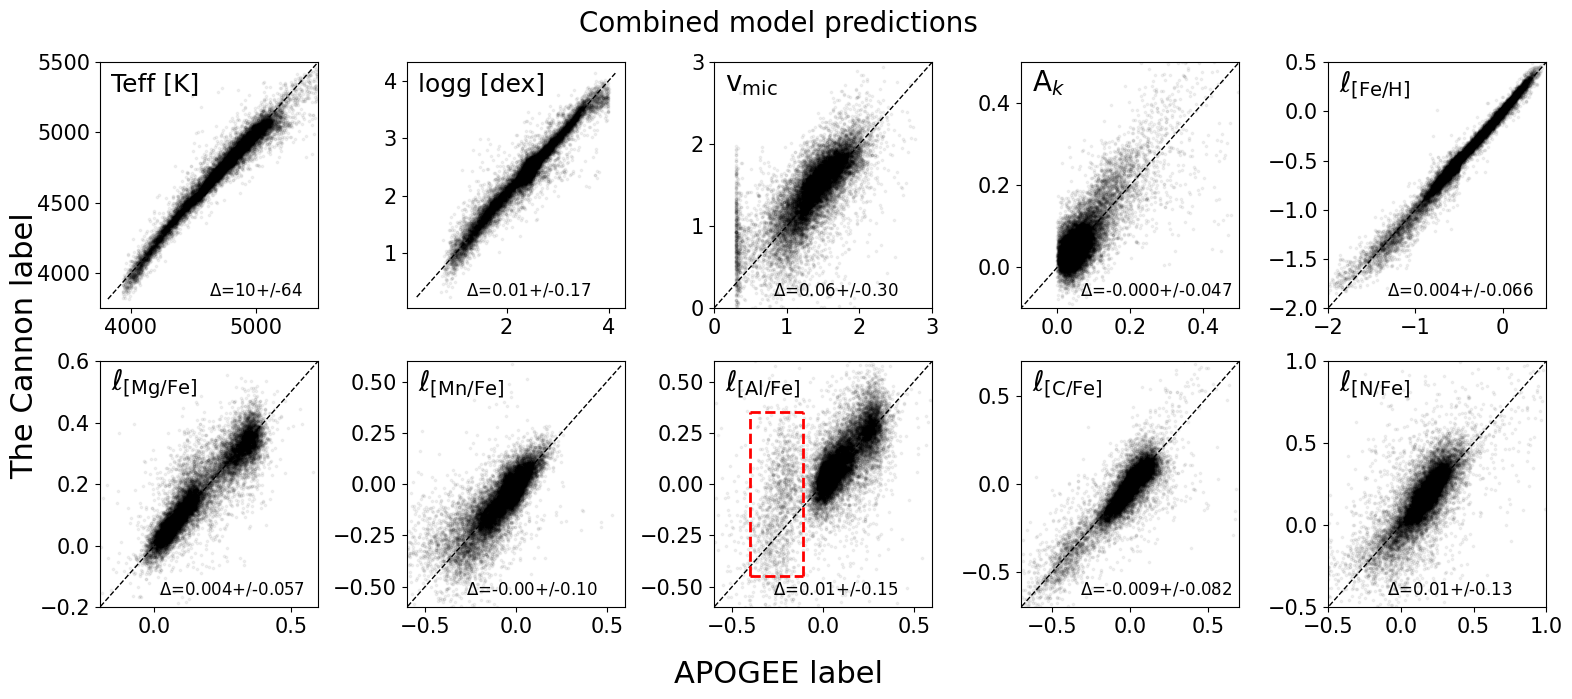

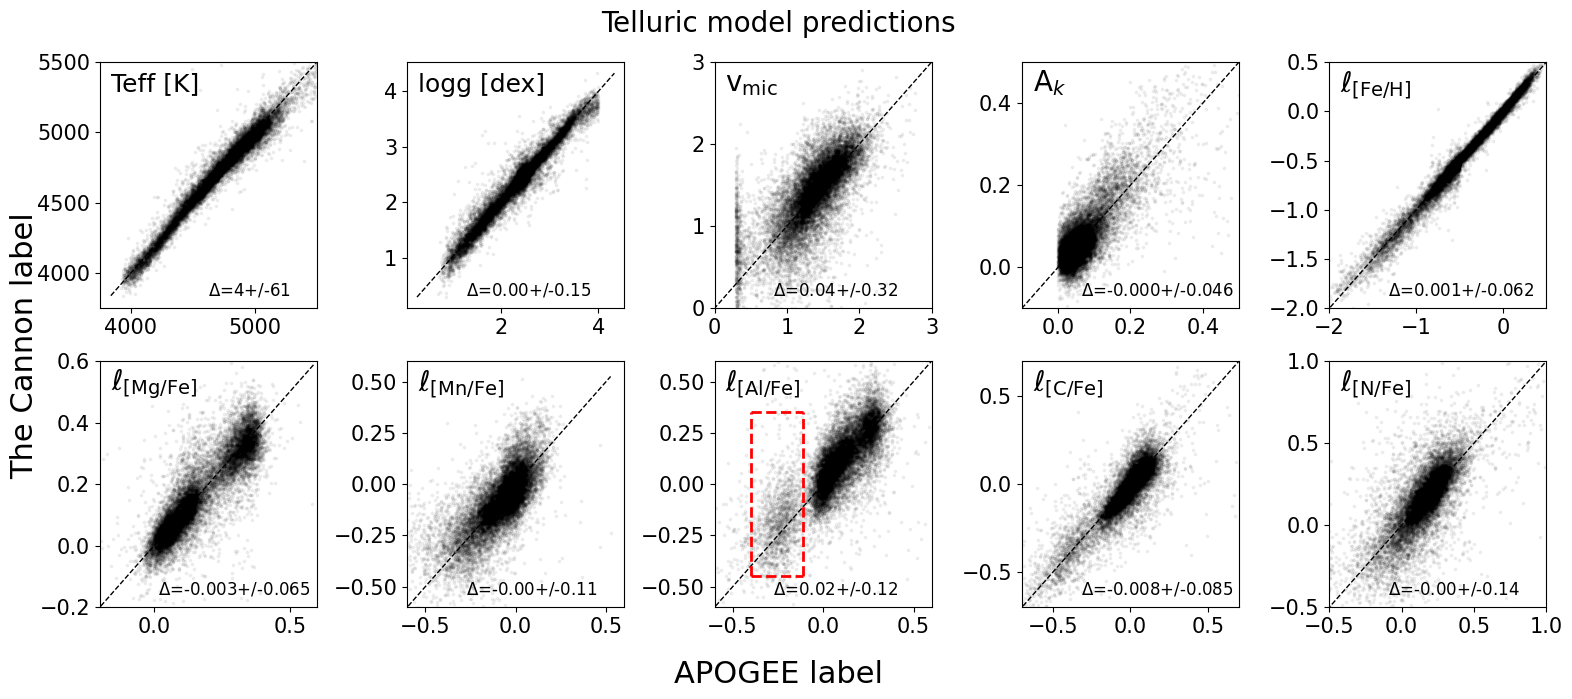

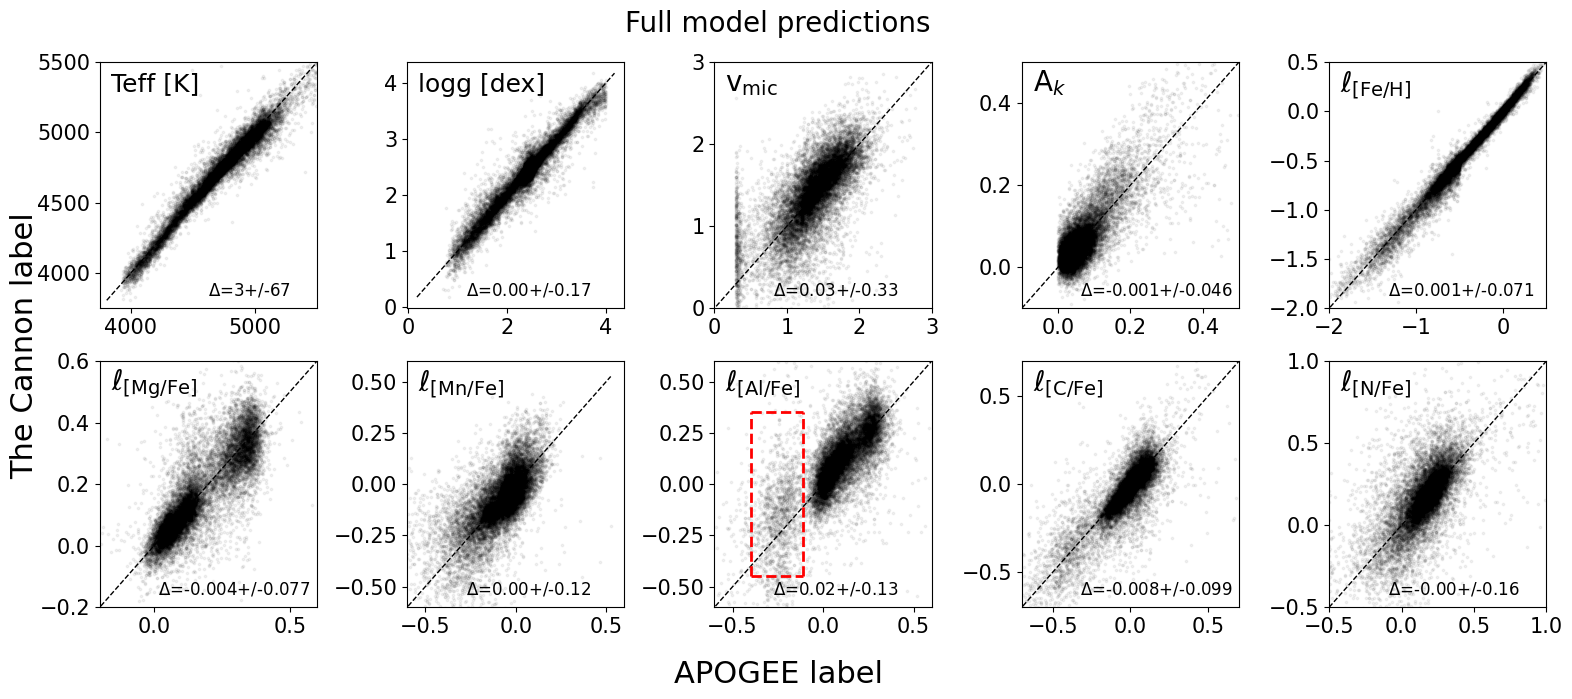

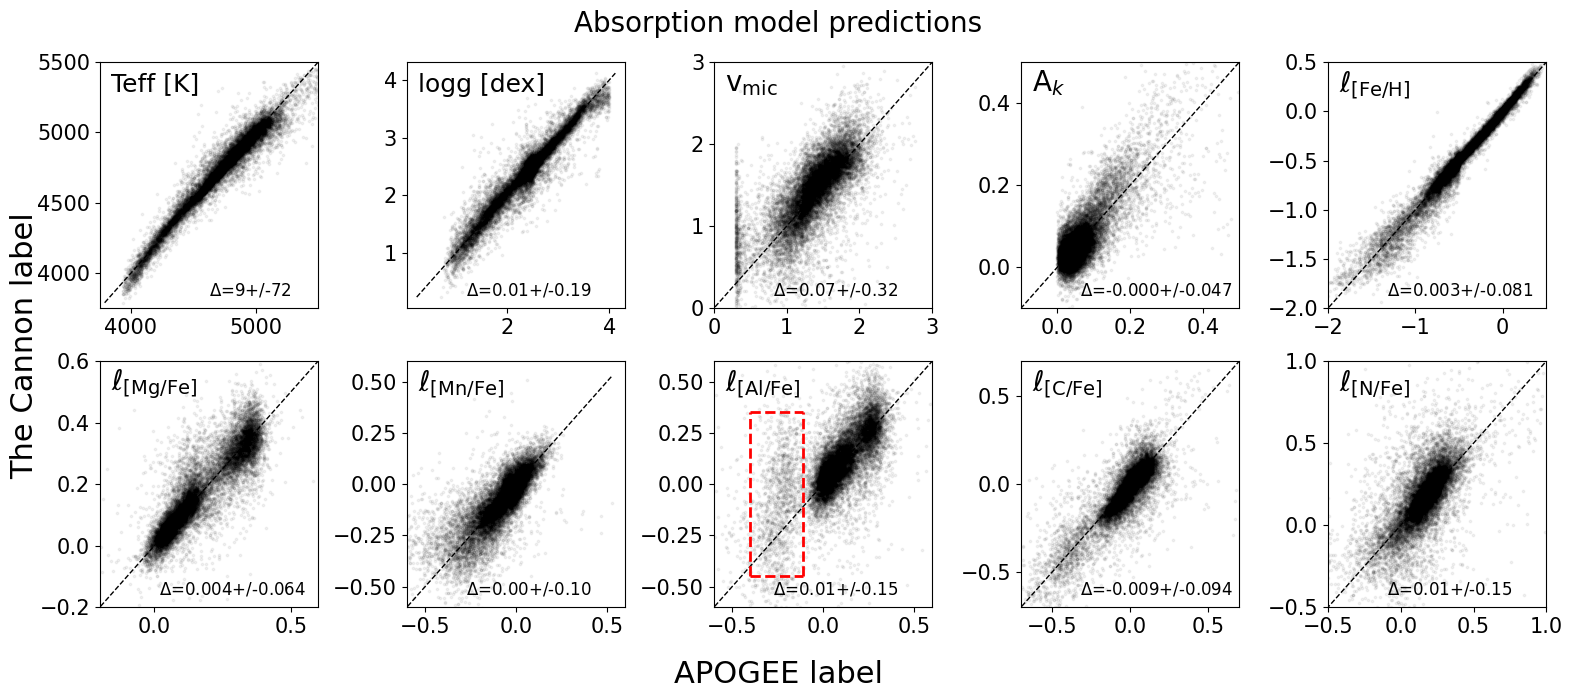

In [108]:
from uncertainties import ufloat

def plot_comparing_models(apogee_table,our_table,variables=['Teff','logg','vmic','Ak','l_feh','l_mg','l_mn','l_al','l_c','l_n'],
                                 color='k',title=None,modelname='combined',fig_title=None,savefig=False,Al_square=False):

    apo_labels = {'Teff':['TEFF','Teff [K]'],   #apoge label , name that I want to write down
                 'logg': ['LOGG','logg [dex]'],
                 'vmic':['VMICRO',r'v$_\text{mic}$'],
                 'Ak':['AK_WISE',r'A$_{k}$'],
                 'l_feh':['FE_H', r'$\ell_\text{[Fe/H]}$'],
                 'l_mg':['MG_FE', r'$\ell_\text{[Mg/Fe]}$'],
                 'l_mn':['MN_FE', r'$\ell_\text{[Mn/Fe]}$'],
                 'l_al':['AL_FE', r'$\ell_\text{[Al/Fe]}$'],
                 'l_c':['C_FE', r'$\ell_\text{[C/Fe]}$'],
                 'l_n':['N_FE', r'$\ell_\text{[N/Fe]}$']
                 }

    label_lims = {'Teff':[3750,5500],
                 'logg': [],
                 'vmic':[0,3],
                 'Ak':[-0.1,0.5],
                 'l_feh':[-2,0.5],
                 'l_mg':[-0.2,0.6],
                 'l_mn':[-0.6,0.6],
                 'l_al':[-0.6,0.6],
                 'l_c':[-0.7,0.7],
                 'l_n':[-0.5,1]}
    
    n_labels = len(variables)
    ncols = len(variables)//2
    nrows = int(np.ceil(n_labels / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows), squeeze=False)

    fit_statistics = dict()
    
    for i, label in enumerate(variables):
        row, col = divmod(i, ncols)
        ax = axs[row, col]

        x = apogee_table[apo_labels[label][0]]
        y = our_table[label]

        #chi2 mask
        chi2_mask = our_table['chi_sq'] < 15000
        x=x[chi2_mask]
        y=y[chi2_mask]

        #1:1 line
        xmin = min(x.min(), y.min())
        xmax = max(x.max(), y.max())
        ax.plot([xmin, xmax], [xmin, xmax], linewidth=1,color=color,ls='--')

        # Plot hexbin
        ax.scatter(x, y, c=color,s=3,alpha=0.05)


        # Residual stats
        diff = (y - x)          #predicted labels - true labels
        bias = np.median(diff)
        std = np.sqrt(np.mean(diff**2)) # rmsd: Root Mean Square Deviation
        bias_u = ufloat(bias, std)
        formatted = f"{bias_u:.2u}"  # Ej: 0.013±0.004
        fit_statistics[f"{apo_labels[label][0]}_{modelname}"] = bias_u
        if i != 0 :ax.text(0.27, 0.05, f"$\\Delta$={formatted}",transform=ax.transAxes, fontsize=12,color='k')
        else: ax.text(0.5, 0.05, f"$\\Delta$={formatted}",transform=ax.transAxes, fontsize=12,color='k')

        
        # Label name
        if i == 0 or i == 1: ax.text(0.05, 0.88, apo_labels[label][1], transform=ax.transAxes,fontsize=18)
        else:                ax.text(0.05, 0.88, apo_labels[label][1], transform=ax.transAxes,fontsize=20)

        # Add x and y ticks explicitly
        ax.tick_params(axis='both', which='both', labelsize=15)
        if len(label_lims[label]) > 0:
            ax.set_xlim(label_lims[label][0],label_lims[label][1])
            ax.set_ylim(label_lims[label][0],label_lims[label][1])

        # Add axis labels only on outer axes
        if row == nrows - 1:
            ax.set_xlabel('', fontsize=12)
        if col == 0:
            ax.set_ylabel('', fontsize=12)

        
        # Al panel square
        if Al_square: 
            if i == 7:
                #ax.vlines(-0.5,-0.11,-1,0.5ls='--')
                ax.vlines(-0.4,-0.45,0.35,ls='--',lw=2,color='red')
                ax.vlines(-0.11,-0.45,0.35,ls='--',lw=2,color='red')
                ax.hlines(-0.45,-0.4,-0.11,ls='--',lw=2,color='red')
                ax.hlines(0.35,-0.4,-0.11,ls='--',lw=2,color='red')

    # Global labels
    fig.supxlabel("APOGEE label", fontsize=22)
    fig.supylabel("The Cannon label", fontsize=22)

    # Remove unused axes
    for j in range(n_labels, nrows * ncols):
        row, col = divmod(j, ncols)
        fig.delaxes(axs[row, col])

    if title:plt.suptitle(title)
    
    plt.subplots_adjust(wspace=0.25, hspace=0.3)
    if fig_title : plt.suptitle(fig_title,fontsize=20)
    plt.tight_layout()
    if savefig: 
        if Al_square: plt.savefig(f'figures/APOGEE_TheCannon_labels_{modelname}_validationset_Alsquared'+'.png',dpi=300,bbox_inches='tight')
        else: plt.savefig(f'figures/APOGEE_TheCannon_labels_{modelname}_validationset'+'.png',dpi=300,bbox_inches='tight')
    plt.show()   

    return fit_statistics


crossval_table_full_model = Table.read(f'output_files/crossvalidation/crossval_table_full_model_15410.csv')
crossval_table_combined_model = Table.read(f'output_files/crossvalidation/crossval_table_combined_model_15410.csv')
crossval_table_telluric_model = Table.read(f'output_files/crossvalidation/crossval_table_telluric_model_15410.csv')
crossval_table_absorption_model = Table.read(f'output_files/crossvalidation/crossval_table_absorption_model_15410.csv')


model_preds_table = crossval_table_combined_model
stats_combined_model = plot_comparing_models(sample_labels[model_preds_table['idx']],
                                              model_preds_table,
                                              variables=['Teff','logg','vmic','Ak','l_feh','l_mg','l_mn','l_al','l_c','l_n'],
                                              fig_title = 'Combined model predictions',
                                            modelname='combined',
                                             savefig=True,
                                            Al_square=True)


model_preds_table = crossval_table_telluric_model
stats_telluric_model = plot_comparing_models(sample_labels[model_preds_table['idx']],
                                              model_preds_table,
                                              variables=['Teff','logg','vmic','Ak','l_feh','l_mg','l_mn','l_al','l_c','l_n'],
                                              fig_title = 'Telluric model predictions',
                                            modelname='telluric',
                                             savefig=False,
                                            Al_square=True)

model_preds_table = crossval_table_full_model
stats_full_model = plot_comparing_models(sample_labels[model_preds_table['idx']],
                                        model_preds_table,
                                        variables=['Teff','logg','vmic','Ak','l_feh','l_mg','l_mn','l_al','l_c','l_n'],
                                        fig_title = 'Full model predictions',
                                        modelname='full',
                                        savefig=True,
                                        Al_square=True)

model_preds_table = crossval_table_absorption_model
stats_absorption_model = plot_comparing_models(sample_labels[model_preds_table['idx']],
                                              model_preds_table,
                                              variables=['Teff','logg','vmic','Ak','l_feh','l_mg','l_mn','l_al','l_c','l_n'],
                                              fig_title = 'Absorption model predictions',
                                              modelname='absorption',
                                              savefig=True,
                                              Al_square=True)

In [109]:
text_path = Path("text_files/")
text_path.mkdir(exist_ok=True)

def print_statistics_table(fit_statistics, selected_labels, selected_elems, model_labels, save_tex=False, filename="text_files/statistics_validation_table_all_models.tex"):
    import uncertainties
    
    models_titles = {'combined': 'Combined model', 'full': 'Full-spectrum model','telluric':'Telluric model','absorption': 'Absorption model'}
    labels_names = {
        'TEFF':'Teff',
        'LOGG':'logg',
        'VMICRO':'Vmic',
        'AK_WISE':'Ak',
        'FE_H':'Fe',
        'MG_FE': 'Mg',
        'MN_FE': 'Mn',
        'AL_FE': 'Al',
        'C_FE': 'C',
        'N_FE': 'N',
    }

    model_names = [models_titles[m] for m in model_labels]

    # --- Format of the table and header ---
    header = ["Label"] + model_names
    row_format = "{:<8}" + " {:>25}" * len(model_labels)
    print(row_format.format(*header))

    # --- Construction of the table ---
    latex_lines = []
    latex_lines.append("\\begin{table*}")
    latex_lines.append("\\centering")
    latex_lines.append("\\begin{tabular}{|l|" + "l|" * len(model_labels) + "}")
    latex_lines.append("\\hline")
    latex_lines.append("Element & " + " & ".join(model_names) + " \\\\ \\hline \\hline")

    for elem_idx in selected_elems:
        label_key = selected_labels[elem_idx]
        label = labels_names[label_key]
        row = [label]
        latex_row = []

        for model in model_labels:
            key = f"{label_key}_{model}"
            if key in fit_statistics:
                bias_u = fit_statistics[key]
                formatted = f"{bias_u:.2u}"
                formatted = formatted.replace("+/-", " \\pm ")
                formatted = f"${formatted}$"
            else:
                formatted = "N/A"
            row.append(formatted)
            latex_row.append(formatted)

        print(row_format.format(*row))
        latex_lines.append(f"{label.replace('[','').replace(']','')} & " + " & ".join(latex_row) + " \\\\ \\hline")

    latex_lines.append("\\end{tabular}")
    latex_lines.append("\\caption{Bias and RMS scatter around the 1:1 line for the predictions of each model.}")
    latex_lines.append("\\label{tab:validation_models}")
    latex_lines.append("\\end{table*}")

    # --- Guardar si se pide ---
    if save_tex:
        with open(filename, "w") as f:
            f.write("\n".join(latex_lines))
        print(f"\n✅ LaTeX table saved to: {filename}")


stats_total = {}
stats = [stats_full_model,stats_absorption_model,stats_telluric_model,stats_combined_model]
for s in stats:
    for k in s:
        stats_total[k] = s[k]
        
print_statistics_table(stats_total,
                       selected_labels=['TEFF','LOGG','VMICRO','AK_WISE','FE_H','MG_FE','MN_FE','AL_FE','C_FE','N_FE'],
                       #'[Fe/H]','[Mg/Fe]','[Mn/Fe]','[Al/Fe]','[C/Fe]','[N/Fe]'],
                       selected_elems=[0,1,2,3,4,5, 6, 7, 8, 9],
                       model_labels=['full','absorption','telluric','combined'],
                      save_tex = True)

Label          Full-spectrum model          Absorption model            Telluric model            Combined model
Teff                    $3 \pm 67$                $9 \pm 72$                $4 \pm 61$               $10 \pm 64$
logg               $0.00 \pm 0.17$           $0.01 \pm 0.19$           $0.00 \pm 0.15$           $0.01 \pm 0.17$
Vmic               $0.03 \pm 0.33$           $0.07 \pm 0.32$           $0.04 \pm 0.32$           $0.06 \pm 0.30$
Ak              $-0.001 \pm 0.046$        $-0.000 \pm 0.047$        $-0.000 \pm 0.046$        $-0.000 \pm 0.047$
Fe               $0.001 \pm 0.071$         $0.003 \pm 0.081$         $0.001 \pm 0.062$         $0.004 \pm 0.066$
Mg              $-0.004 \pm 0.077$         $0.004 \pm 0.064$        $-0.003 \pm 0.065$         $0.004 \pm 0.057$
Mn                 $0.00 \pm 0.12$           $0.00 \pm 0.10$          $-0.00 \pm 0.11$          $-0.00 \pm 0.10$
Al                 $0.02 \pm 0.13$           $0.01 \pm 0.15$           $0.02 \pm 0.12$          